In [1]:
from google.colab import files

uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv("ai4i2020.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Scikit-learn import successful!")
display(df.head())

Dataset loaded successfully!
Dataset shape: (10000, 14)
Scikit-learn import successful!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMachine Failure Counts:")
print(df["Machine failure"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

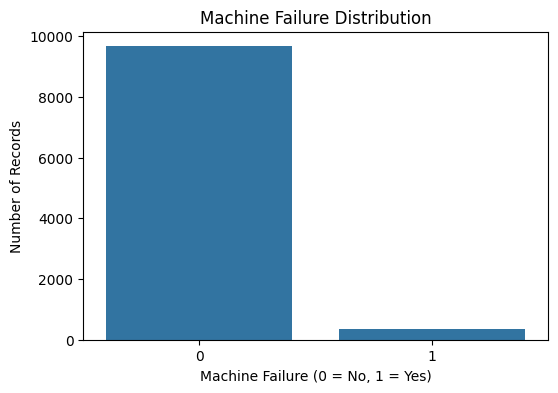

In [4]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Machine failure")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.show()

In [5]:

# Create a new temperature feature
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

# Select useful input features
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference [K]"
]

X = df[features]
y = df["Machine failure"]

# Convert machine type into numeric columns
X = pd.get_dummies(
    X, columns=["Type"], drop_first=True, dtype=int
)

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training completed successfully!")

Training data: (8000, 8)
Testing data: (2000, 8)
Training completed successfully!


In [6]:

# Train Logistic Regression model
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# Predict machine failures
y_pred = model.predict(X_test)

# Evaluate the model
print("Logistic Regression Results")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



In [7]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Results")
print(classification_report(
    y_test,
    dt_pred,
    zero_division=0
))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.37      0.81      0.51        68

    accuracy                           0.95      2000
   macro avg       0.68      0.88      0.74      2000
weighted avg       0.97      0.95      0.96      2000



In [8]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

Random Forest Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.60      0.73        68

    accuracy                           0.98      2000
   macro avg       0.96      0.80      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [9]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 3),
        "F1 Score": round(f1_score(y_test, pred, zero_division=0), 3)
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("Recall", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828,0.144,0.824,0.245
1,Decision Tree,0.948,0.374,0.809,0.512
2,Random Forest,0.985,0.932,0.603,0.732


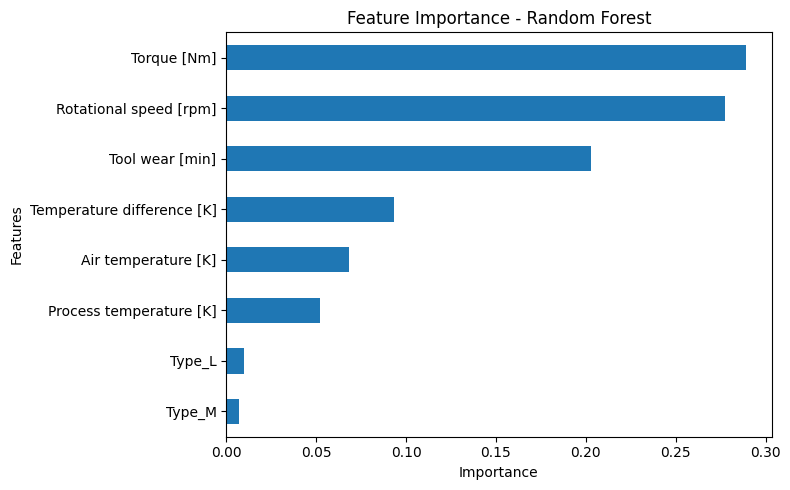

In [10]:

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Cost-Sensitive Random Forest Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.66      0.78        68

    accuracy                           0.99      2000
   macro avg       0.96      0.83      0.88      2000
weighted avg       0.99      0.99      0.99      2000



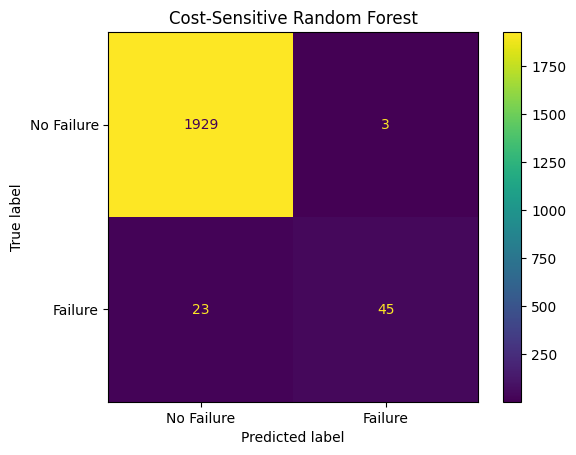

In [11]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Give higher importance to machine failures
cost_model = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1, 1: 10},
    random_state=42,
    n_jobs=-1
)

cost_model.fit(X_train, y_train)

cost_pred = cost_model.predict(X_test)

print("Cost-Sensitive Random Forest Results")
print(classification_report(
    y_test,
    cost_pred,
    zero_division=0
))

cm = confusion_matrix(y_test, cost_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Cost-Sensitive Random Forest")
plt.show()

In [12]:

final_models = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Cost-Sensitive Random Forest": cost_pred
}

final_results = []

for name, pred in final_models.items():
    final_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 3),
        "F1 Score": round(f1_score(y_test, pred, zero_division=0), 3)
    })

final_df = pd.DataFrame(final_results)
display(final_df.sort_values("Recall", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828,0.144,0.824,0.245
1,Decision Tree,0.948,0.374,0.809,0.512
3,Cost-Sensitive Random Forest,0.987,0.938,0.662,0.776
2,Random Forest,0.985,0.932,0.603,0.732


Confusion Matrix:
[[1929    3]
 [  23   45]]


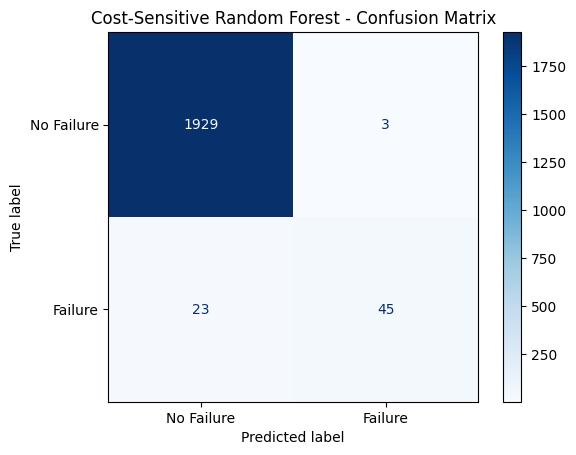

In [13]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, cost_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)
disp.plot(cmap="Blues")
plt.title("Cost-Sensitive Random Forest - Confusion Matrix")
plt.show()

In [14]:

import joblib

joblib.dump(cost_model, "machine_failure_model.pkl")
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [15]:

machine_type = input("Machine type (L, M, H): ").upper()
air_temp = float(input("Air temperature [K]: "))
process_temp = float(input("Process temperature [K]: "))
speed = float(input("Rotational speed [rpm]: "))
torque = float(input("Torque [Nm]: "))
tool_wear = float(input("Tool wear [min]: "))

new_data = pd.DataFrame([{
    "Air temperature [K]": air_temp,
    "Process temperature [K]": process_temp,
    "Rotational speed [rpm]": speed,
    "Torque [Nm]": torque,
    "Tool wear [min]": tool_wear,
    "Temperature difference [K]": process_temp - air_temp,
    "Type_M": int(machine_type == "M"),
    "Type_L": int(machine_type == "L")
}])

new_data = new_data.reindex(
    columns=X_train.columns,
    fill_value=0
)

prediction = cost_model.predict(new_data)[0]
probability = cost_model.predict_proba(new_data)[0][1]

print("\nPredicted failure:", "YES" if prediction == 1 else "NO")
print("Estimated failure probability:", round(probability * 100, 2), "%")

Machine type (L, M, H): m
Air temperature [K]: 300
Process temperature [K]: 310
Rotational speed [rpm]: 1200
Torque [Nm]: 40
Tool wear [min]: 100

Predicted failure: NO
Estimated failure probability: 1.5 %


In [16]:

# Save final model comparison
final_df.to_csv("model_comparison_results.csv", index=False)

print("Final comparison table:")
display(final_df)

print("\nResults saved successfully!")

Final comparison table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828,0.144,0.824,0.245
1,Decision Tree,0.948,0.374,0.809,0.512
2,Random Forest,0.985,0.932,0.603,0.732
3,Cost-Sensitive Random Forest,0.987,0.938,0.662,0.776



Results saved successfully!


In [ ]:

print("PROJECT CONCLUSION")
print("------------------")
print("1. AI4I 2020 dataset was used.")
print("2. Four machine learning models were compared.")
print("3. Cost-sensitive Random Forest achieved the")
print("   highest F1-score in our experiment.")
print("4. Failure recall and false alarms are important")
print("   for predictive maintenance.")
print("5. The model predicts machine failure from")
print("   machine operating measurements.")

PROJECT CONCLUSION
------------------
1. AI4I 2020 dataset was used.
2. Four machine learning models were compared.
3. Cost-sensitive Random Forest achieved the
   highest F1-score in our experiment.
4. Failure recall and false alarms are important
   for predictive maintenance.
5. The model predicts machine failure from
   machine operating measurements.
